# **Space Weather Prediction Using Machine Learning**
This notebook aims to predict significant space weather events, such as solar flares and geomagnetic storms,
by analyzing historical data from sources like NOAA's Space Weather Prediction Center (SWPC).

## **1. Project Setup and Planning**

### 1.1 Clarify Objectives & Goals
- **Objective**: Build a model to forecast solar flares (classification) or geomagnetic indices (regression).
- **Success Criteria**: Compare the model’s accuracy (MAE, RMSE, etc.) to naive or established baselines.

### 1.2 Define Scope & Constraints
- **Scope**: Work primarily with NOAA data. Time horizon for forecasting: e.g., next 24 hours.
- **Constraints**: Limited hardware in Colab. Data may be large or require cleaning.

### 1.3 Set Up Environment
- **Libraries**: Numpy, Pandas, Matplotlib, Scikit-Learn, TensorFlow/PyTorch.
- **Version Control**: Plan to use Git or GitHub for code management.

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
import torch

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Scikit-Learn version:", sklearn.__version__)
print("TensorFlow version:", tf.__version__)
print("PyTorch version:", torch.__version__)

NumPy version: 2.0.0
Pandas version: 2.2.2
Matplotlib version: 3.9.1
Scikit-Learn version: 1.5.1
TensorFlow version: 2.18.0
PyTorch version: 2.6.0


# **2. Data Collection**

We will acquire our historical space weather data from NOAA’s Space Weather Prediction Center (SWPC). Specifically, we want:
1. **Geomagnetic indices** (e.g., Kp index). ([Geomagnetic Indicies Data Source](https://kp.gfz.de/en/data))
2. **Solar wind measurements** (speed, density, magnetic field components).
3. **Solar flare data** (occurrence times, intensities, and classes). ([Solar Flare Data Source](https://hesperia.gsfc.nasa.gov/rhessi3/data-access/rhessi-data/flare-list/index.html))

Our goal is to gather data covering at least five years (2015–2020) so the model can learn from a variety of solar conditions and storm events. The final dataset will be consolidated into a single DataFrame for subsequent preprocessing and modeling steps.

1. **Geomagnetic and Solar Indices Dataset** (`GeomagneticandSolarIndicies.csv`):
    - **Year:** Calendar year for the UT day.
    - **Month:** Month (MM) of the observation.
    - **Day:** Day (DD) of the observation.
    - **Days_Since_1932:** Number of days since January 1, 1932 (start of the UT day).
    - **Days_Since_1932_Mid:** Days since January 1, 1932 plus 0.5, representing midday (12:00 UT).
    - **Bartels_Rotation:** Bartels solar rotation number (27-day rotation period count).
    - **Day_in_Rotation:** Day number within the current Bartels rotation period.
    - **Kp_00_03, Kp_03_06, ..., Kp_21_24:** Eight three-hourly Kp index values for the respective UT day intervals:
        - 00:00–03:00, 03:00–06:00, 06:00–09:00, 09:00–12:00, 12:00–15:00, 15:00–18:00, 18:00–21:00, 21:00–24:00.
    - **ap_00_03, ap_03_06, ..., ap_21_24:** Eight three-hourly ap index values for the same intervals.
    - **Daily_Ap:** The daily equivalent planetary amplitude (average of the eight ap values).
    - **Sunspot_Number:** The International Sunspot Number for the day.
    - **F10.7_Obs:** Observed solar radio flux at 10.7 cm (in solar flux units, s.f.u.).
    - **F10.7_Adj:** Adjusted solar radio flux at 10.7 cm.
    - **Data_Flag:** Indicates data quality:
        - 0: Both Kp and SN values are preliminary.
        - 1: Kp is definitive, but SN is preliminary.
        - 2: Both Kp and SN values are definitive.

2. **HESSI Flare List Dataset** (`hessi_flare_list.csv`):
    - **Flare:** Unique identifier for the flare event.
    - **Start_Date:** Date when the flare started (e.g., "12-Feb-2002").
    - **Start_Time:** Time when the flare began (HH:MM:SS).
    - **Peak_Time:** Time when the flare reached its maximum intensity.
    - **End_Time:** Time when the flare ended.
    - **Duration:** Duration of the flare in seconds.
    - **Peak_Cps:** Peak counts per second (cps) recorded during the flare.
    - **Total_Counts:** Total counts recorded for the flare event.
    - **Energy_Range:** Energy range (in keV) over which the flare was observed (e.g., "25-50").
    - **X_Pos:** X-coordinate (in arcseconds) of the flare’s position on the solar disk.
    - **Y_Pos:** Y-coordinate (in arcseconds) of the flare’s position.
    - **Radial:** Radial distance (in arcseconds) from the center of the solar disk.
    - **AR:** Active Region number associated with the flare.
    
    Following these fixed fields, there are binary columns corresponding to various **Flare Flags**. Each flag is set to:
    - **1:** If the flag is present during the flare.
    - **0:** Otherwise.
    
    The flags include:
    - **A0, A1, A2, A3:** Attenuator states.
    - **DF, DR:** Decimation flags for front and rear segments.
    - **ED, EE, ES:** Indicate spacecraft eclipse conditions.
    - **FE, FR, FS:** Indicate flare ongoing conditions or fast rate mode.
    - **GD, GE, GS:** Data gap indicators.
    - **MR, NS, PE, PS:** Additional flags for spacecraft state, non-solar events, particle events, or position quality.
    - **PN, QN:** Position and data quality flags.
    - **SD, SE, SS:** Indicate spacecraft in SAA (South Atlantic Anomaly) during the flare.
    
This detailed description helps in understanding the features available in each dataset and guides further analysis.

---

## 2.1 Data Retrieval

Below, we demonstrate how to fetch the data. If you have already downloaded your CSV files from NOAA SWPC (e.g., from an FTP server or web endpoint), place them in your Google Drive, then mount the drive. Otherwise, if you prefer to download directly, you can use `wget` or `requests`. For this project, I will place pre-downloaded CSV files into my Drive to ensure data availability.

```python
# 2.1.1 - Mount Google Drive to access pre-downloaded CSV files
from google.colab import drive
drive.mount('/content/drive')

# Adjust the path to where your CSV files are stored.
data_path_kp = "/content/drive/MyDrive/space_weather_project/kp_2015_2020.csv"
data_path_wind = "/content/drive/MyDrive/space_weather_project/solar_wind_2015_2020.csv"
data_path_flares = "/content/drive/MyDrive/space_weather_project/solar_flares_2015_2020.csv"

In [11]:
import pandas as pd

# Load the Geomagnetic and Solar Indices dataset
geomagnetic_df = pd.read_csv("GeomagneticandSolarIndicies.csv")
print("Geomagnetic and Solar Indices Dataset:")
print(geomagnetic_df.head())
print("\nColumns in Geomagnetic and Solar Indices Dataset:")
print(geomagnetic_df.columns.tolist())

# Load the HESSI Flare List dataset
flare_df = pd.read_csv("hessi_flare_list.csv")
print("\nHESSI Flare List Dataset:")
print(flare_df.head())
print("\nColumns in HESSI Flare List Dataset:")
print(flare_df.columns.tolist())

Geomagnetic and Solar Indices Dataset:
   Year  Month  Day  Days_Since_1932  Days_Since_1932_Mid  Bartels_Rotation  \
0  1932      1    1                0                  0.5              1352   
1  1932      1    2                1                  1.5              1352   
2  1932      1    3                2                  2.5              1352   
3  1932      1    4                3                  3.5              1352   
4  1932      1    5                4                  4.5              1352   

   Day_in_Rotation  Kp_00_03  Kp_03_06  Kp_06_09  ...  ap_09_12  ap_12_15  \
0               10     3.333     2.667     2.333  ...        12        18   
1               11     3.667     3.667     3.333  ...        22        18   
2               12     3.333     3.333     3.000  ...         4         9   
3               13     2.000     0.333     1.000  ...         0         4   
4               14     0.000     0.000     0.333  ...         3         2   

   ap_15_18  ap_18_21  

/var/folders/cf/s4svr56918b_02n7yzvc_kxc0000gn/T/ipykernel_34407/2059369799.py:11: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  flare_df = pd.read_csv("hessi_flare_list.csv")


### Geomagnetic and Solar Indices Dataset Information ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33970 entries, 0 to 33969
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 33970 non-null  int64  
 1   Month                33970 non-null  int64  
 2   Day                  33970 non-null  int64  
 3   Days_Since_1932      33970 non-null  int64  
 4   Days_Since_1932_Mid  33970 non-null  float64
 5   Bartels_Rotation     33970 non-null  int64  
 6   Day_in_Rotation      33970 non-null  int64  
 7   Kp_00_03             33970 non-null  float64
 8   Kp_03_06             33970 non-null  float64
 9   Kp_06_09             33970 non-null  float64
 10  Kp_09_12             33970 non-null  float64
 11  Kp_12_15             33970 non-null  float64
 12  Kp_15_18             33970 non-null  float64
 13  Kp_18_21             33970 non-null  float64
 14  Kp_21_24             33970 n

,Year,Month,Day,Days_Since_1932,Days_Since_1932_Mid,Bartels_Rotation,Day_in_Rotation,Kp_00_03,Kp_03_06,Kp_06_09,...,ap_09_12,ap_12_15,ap_15_18,ap_18_21,ap_21_24,Daily_Ap,Sunspot_Number,F10.7_Obs,F10.7_Adj,Data_Flag
count,33970.000000,33970.000000,33970.000000,33970.000000,33970.000000,33970.000000,33970.000000,33970.000000,33970.000000,33970.000000,...,33970.000000,33970.000000,33970.000000,33970.000000,33970.000000,33970.000000,33970.000000,33970.000000,33970.000000,33970.000000
mean,1978.001384,6.522667,15.729497,16984.500000,16985.000000,1980.907418,13.999706,2.265231,2.230656,2.094154,...,12.020194,12.720901,13.155461,13.712570,13.975684,13.318428,93.227848,101.699193,101.703406,1.997262
std,26.847052,3.448861,8.800579,9806.438659,9806.438659,363.201642,7.788594,1.489411,1.494414,1.445043,...,17.387370,18.694402,19.859603,20.579123,20.620470,15.349129,83.037734,68.874752,68.802688,0.052252
min,1932.000000,1.000000,1.000000,0.000000,0.500000,1352.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,1.000000
25%,1955.000000,4.000000,8.000000,8492.250000,8492.750000,1666.000000,7.000000,1.000000,1.000000,1.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,23.000000,70.100000,70.100000,2.000000
50%,1978.000000,7.000000,16.000000,16984.500000,16985.000000,1981.000000,14.000000,2.000000,2.000000,2.000000,...,6.000000,7.000000,7.000000,7.000000,7.000000,9.000000,73.000000,92.200000,92.300000,2.000000
75%,2001.000000,10.000000,23.000000,25476.750000,25477.250000,2295.000000,21.000000,3.333000,3.333000,3.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,16.000000,146.000000,145.900000,146.000000,2.000000
max,2025.000000,12.000000,31.000000,33969.000000,33969.500000,2610.000000,27.000000,9.000000,9.000000,9.000000,...,400.000000,400.000000,400.000000,400.000000,400.000000,280.000000,503.000000,938.600000,924.400000,2.000000



Missing Values:
Year                   0
Month                  0
Day                    0
Days_Since_1932        0
Days_Since_1932_Mid    0
Bartels_Rotation       0
Day_in_Rotation        0
Kp_00_03               0
Kp_03_06               0
Kp_06_09               0
Kp_09_12               0
Kp_12_15               0
Kp_15_18               0
Kp_18_21               0
Kp_21_24               0
ap_00_03               0
ap_03_06               0
ap_06_09               0
ap_09_12               0
ap_12_15               0
ap_15_18               0
ap_18_21               0
ap_21_24               0
Daily_Ap               0
Sunspot_Number         0
F10.7_Obs              0
F10.7_Adj              0
Data_Flag              0
dtype: int64


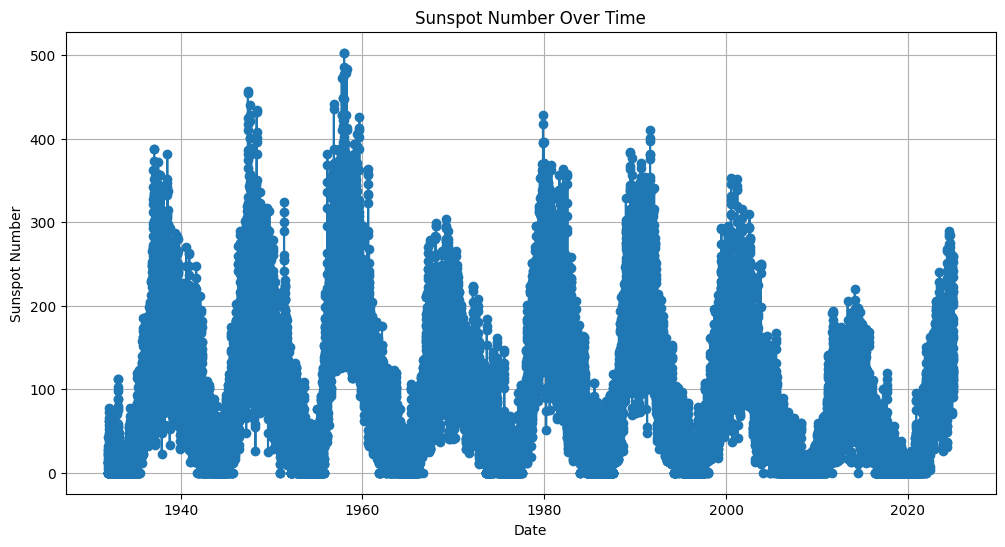

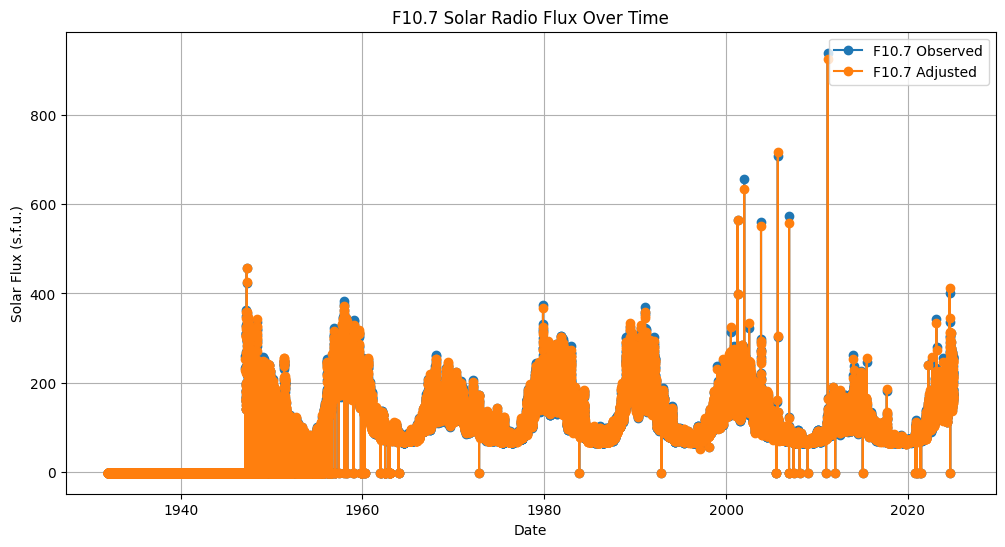

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Geomagnetic and Solar Indices dataset
geomagnetic_df = pd.read_csv("GeomagneticandSolarIndicies.csv")

# Display basic information
print("### Geomagnetic and Solar Indices Dataset Information ###")
geomagnetic_df.info()
print("\nSummary Statistics:")
display(geomagnetic_df.describe())

# Check for missing values
print("\nMissing Values:")
print(geomagnetic_df.isnull().sum())

# Create a datetime column for time series analysis using Year, Month, Day.
geomagnetic_df['Date'] = pd.to_datetime(geomagnetic_df[['Year', 'Month', 'Day']])

# Plot Sunspot Number over time
plt.figure(figsize=(12, 6))
plt.plot(geomagnetic_df['Date'], geomagnetic_df['Sunspot_Number'], marker='o', linestyle='-')
plt.title("Sunspot Number Over Time")
plt.xlabel("Date")
plt.ylabel("Sunspot Number")
plt.grid(True)
plt.show()

# Plot F10.7 Observed and Adjusted Solar Flux over time
plt.figure(figsize=(12, 6))
plt.plot(geomagnetic_df['Date'], geomagnetic_df['F10.7_Obs'], marker='o', linestyle='-', label='F10.7 Observed')
plt.plot(geomagnetic_df['Date'], geomagnetic_df['F10.7_Adj'], marker='o', linestyle='-', label='F10.7 Adjusted')
plt.title("F10.7 Solar Radio Flux Over Time")
plt.xlabel("Date")
plt.ylabel("Solar Flux (s.f.u.)")
plt.legend()
plt.grid(True)
plt.show()

/var/folders/cf/s4svr56918b_02n7yzvc_kxc0000gn/T/ipykernel_34407/1425756164.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  flare_df = pd.read_csv("hessi_flare_list.csv")


### HESSI Flare List Dataset Information ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104036 entries, 0 to 104035
Data columns (total 37 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Flare         104036 non-null  int64 
 1   Start_Date    104036 non-null  object
 2   Start_Time    104036 non-null  object
 3   Peak_Time     104036 non-null  object
 4   End_Time      104036 non-null  object
 5   Duration      104036 non-null  object
 6   Peak_Cps      104036 non-null  object
 7   Total_Counts  104036 non-null  object
 8   Energy_Range  104036 non-null  object
 9   X_Pos         104036 non-null  int64 
 10  Y_Pos         104036 non-null  int64 
 11  Radial        104036 non-null  object
 12  AR            104036 non-null  object
 13  A0            104036 non-null  int64 
 14  A1            104036 non-null  int64 
 15  A2            104036 non-null  int64 
 16  A3            104036 non-null  int64 
 17  DF            104036 n

,Flare,Start_Date,Start_Time,Peak_Time,End_Time,Duration,Peak_Cps,Total_Counts,Energy_Range,X_Pos,...,GS,MR,NS,PE,PS,PN,QN,SD,SE,SS
count,1.040360e+05,104036,104036,104036,104036,104036,104036,104036,104036,104036.000000,...,104036.000000,104036.0,104036.000000,104036.000000,104036.000000,104036.000000,104036.000000,104036.0,104036.000000,104036.000000
unique,NaN,4718,21399,21407,21421,1064,7404,91431,79,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,1-Nov-2014,06:44:56,02:40:14,01:44:56,140,34,50-100,6-12,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,135,19,17,16,728,1260,13,72566,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.228783e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.120920,...,0.001432,0.0,0.005979,0.547147,0.033604,0.960418,0.861932,0.0,0.078425,0.075128
std,1.440844e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,694.186113,...,0.037817,0.0,0.077091,0.497775,0.180208,0.194977,0.344973,0.0,0.268840,0.263599
min,2.021213e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1224.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,5.012041e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-703.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,0.000000,0.000000
50%,1.204222e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.000000,0.0,0.000000,1.000000,0.000000,1.000000,1.000000,0.0,0.000000,0.000000
75%,1.410032e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,717.000000,...,0.000000,0.0,0.000000,1.000000,0.000000,1.000000,1.000000,0.0,0.000000,0.000000



Missing Values:
Flare           0
Start_Date      0
Start_Time      0
Peak_Time       0
End_Time        0
Duration        0
Peak_Cps        0
Total_Counts    0
Energy_Range    0
X_Pos           0
Y_Pos           0
Radial          0
AR              0
A0              0
A1              0
A2              0
A3              0
DF              0
DR              0
ED              0
EE              0
ES              0
FE              0
FR              0
FS              0
GD              0
GE              0
GS              0
MR              0
NS              0
PE              0
PS              0
PN              0
QN              0
SD              0
SE              0
SS              0
dtype: int64

Total Number of Flares: 104036


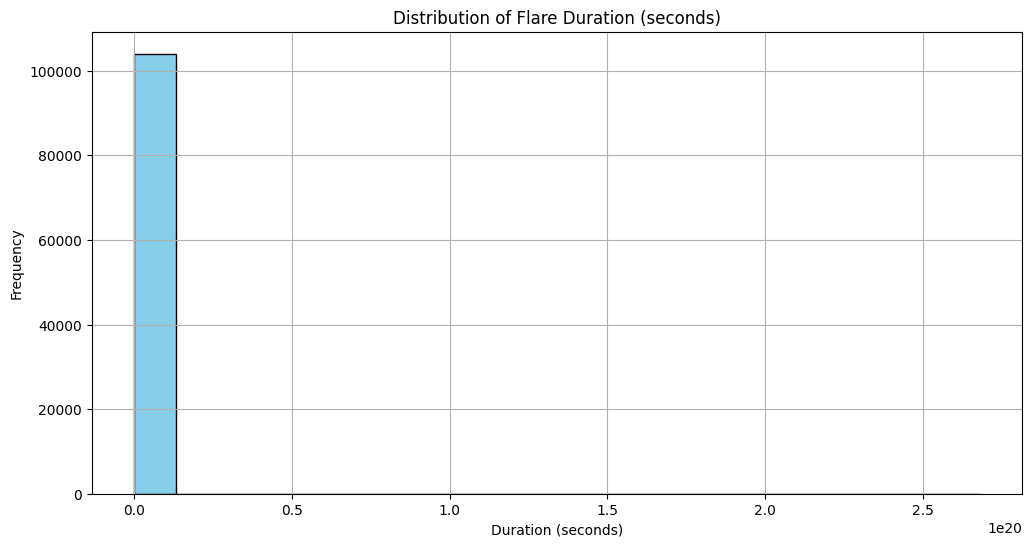

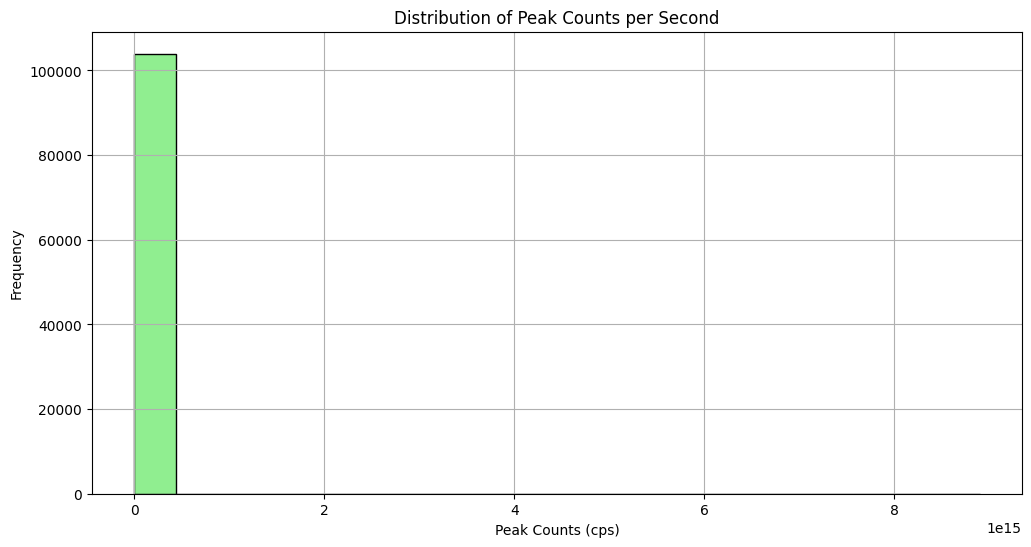

Flag Counts:
A0    100866
A1      8483
A2         2
A3       477
DF     38810
DR     43349
ED         0
EE     12037
ES     14602
FE         0
FR         0
FS         0
GD       903
GE       144
GS       149
MR         0
NS       622
PE     56923
PS      3496
PN     99918
QN     89672
SD         0
SE      8159
SS      7816
dtype: int64


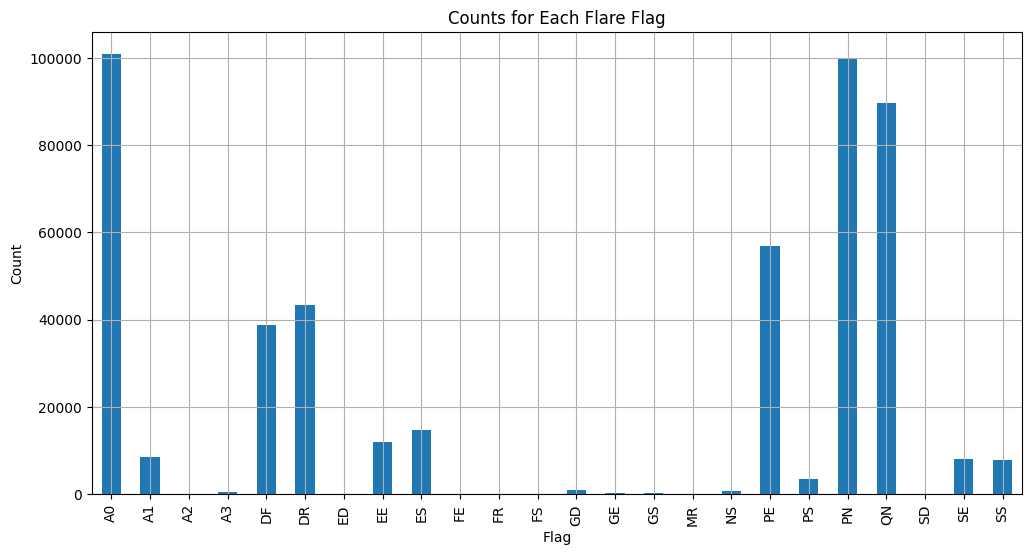

In [13]:
# Load the HESSI Flare List dataset
flare_df = pd.read_csv("hessi_flare_list.csv")

# Display basic information
print("### HESSI Flare List Dataset Information ###")
flare_df.info()
print("\nSummary Statistics:")
display(flare_df.describe(include='all'))

# Check for missing values
print("\nMissing Values:")
print(flare_df.isnull().sum())

# Total number of flares
print("\nTotal Number of Flares:", len(flare_df))

# Plot distribution of Flare Duration
plt.figure(figsize=(12, 6))
# Convert duration to numeric (in case it's read as string)
flare_df['Duration'] = pd.to_numeric(flare_df['Duration'], errors='coerce')
plt.hist(flare_df['Duration'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Flare Duration (seconds)")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Plot distribution of Peak Counts per Second
plt.figure(figsize=(12, 6))
flare_df['Peak_Cps'] = pd.to_numeric(flare_df['Peak_Cps'], errors='coerce')
plt.hist(flare_df['Peak_Cps'].dropna(), bins=20, color='lightgreen', edgecolor='black')
plt.title("Distribution of Peak Counts per Second")
plt.xlabel("Peak Counts (cps)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Summarize flare flag occurrences (binary columns)
# Assuming flag columns are the ones that are not in the fixed fields.
fixed_fields = ["Flare", "Start_Date", "Start_Time", "Peak_Time", "End_Time", 
                "Duration", "Peak_Cps", "Total_Counts", "Energy_Range", 
                "X_Pos", "Y_Pos", "Radial", "AR"]
flag_columns = [col for col in flare_df.columns if col not in fixed_fields]

# Compute counts for each flag
flag_counts = flare_df[flag_columns].sum()
print("Flag Counts:")
print(flag_counts)

# Plot flag counts
plt.figure(figsize=(12, 6))
flag_counts.plot(kind='bar')
plt.title("Counts for Each Flare Flag")
plt.xlabel("Flag")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Part 3: Data Preprocessing

In this section, we prepare our datasets for modeling by performing the following preprocessing steps:

1. **Geomagnetic and Solar Indices Dataset** (`GeomagneticandSolarIndicies.csv`)
    - **Date Conversion:** Combine the Year, Month, and Day columns into a proper datetime column.
    - **Missing Values & Data Cleaning:** Identify and handle any missing values.
    - **Feature Engineering:** Create additional features such as:
        - **Average Kp:** Compute the daily average of the eight three-hourly Kp values.
        - **Average ap:** Compute the daily average of the eight three-hourly ap values.
        - **Resampling/Indexing:** Set the datetime column as the index for time series analysis.

2. **HESSI Flare List Dataset** (`hessi_flare_list.csv`)
    - **Datetime Parsing:** Combine the `Start_Date` and `Start_Time` columns into a single datetime column.
    - **Additional Feature Engineering:** 
        - Convert `Duration` into a numeric value (if not already).
        - Compute derived features (if needed) such as the time gap between consecutive flares.
    - **Flag Consistency:** Ensure that all flag columns are numeric (0 or 1) for later modeling.

After preprocessing, both datasets will be in a clean, consistent format that is ready for exploratory analysis and model development.

In [14]:
import pandas as pd
import numpy as np

# Load the Geomagnetic and Solar Indices dataset.
geomagnetic_df = pd.read_csv("GeomagneticandSolarIndicies.csv")

# --- 1. Date Conversion ---
# Create a datetime column using the Year, Month, and Day columns.
geomagnetic_df['Date'] = pd.to_datetime(geomagnetic_df[['Year', 'Month', 'Day']])

# --- 2. Missing Values & Data Cleaning ---
# Check for missing values in the critical columns.
missing_summary = geomagnetic_df.isnull().sum()
print("Missing values in Geomagnetic and Solar Indices Dataset:\n", missing_summary)

# For this project, we assume missing values are few; if any are present, we drop them.
geomagnetic_df.dropna(inplace=True)

# --- 3. Feature Engineering ---
# Calculate daily average Kp from the eight three-hourly values.
kp_columns = ["Kp_00_03", "Kp_03_06", "Kp_06_09", "Kp_09_12", 
              "Kp_12_15", "Kp_15_18", "Kp_18_21", "Kp_21_24"]
geomagnetic_df['Avg_Kp'] = geomagnetic_df[kp_columns].mean(axis=1)

# Calculate daily average ap from the eight three-hourly values.
ap_columns = ["ap_00_03", "ap_03_06", "ap_06_09", "ap_09_12", 
              "ap_12_15", "ap_15_18", "ap_18_21", "ap_21_24"]
geomagnetic_df['Avg_ap'] = geomagnetic_df[ap_columns].mean(axis=1)

# Optionally, you might drop the original eight Kp and ap columns if not needed further.
# geomagnetic_df.drop(columns=kp_columns + ap_columns, inplace=True)

# --- 4. Setting the Date as the Index ---
geomagnetic_df.set_index('Date', inplace=True)

# Display the first few rows of the preprocessed Geomagnetic dataset.
print("\nPreprocessed Geomagnetic and Solar Indices Dataset:")
display(geomagnetic_df.head())

Missing values in Geomagnetic and Solar Indices Dataset:
 Year                   0
Month                  0
Day                    0
Days_Since_1932        0
Days_Since_1932_Mid    0
Bartels_Rotation       0
Day_in_Rotation        0
Kp_00_03               0
Kp_03_06               0
Kp_06_09               0
Kp_09_12               0
Kp_12_15               0
Kp_15_18               0
Kp_18_21               0
Kp_21_24               0
ap_00_03               0
ap_03_06               0
ap_06_09               0
ap_09_12               0
ap_12_15               0
ap_15_18               0
ap_18_21               0
ap_21_24               0
Daily_Ap               0
Sunspot_Number         0
F10.7_Obs              0
F10.7_Adj              0
Data_Flag              0
Date                   0
dtype: int64

Preprocessed Geomagnetic and Solar Indices Dataset:


,Year,Month,Day,Days_Since_1932,Days_Since_1932_Mid,Bartels_Rotation,Day_in_Rotation,Kp_00_03,Kp_03_06,Kp_06_09,...,ap_15_18,ap_18_21,ap_21_24,Daily_Ap,Sunspot_Number,F10.7_Obs,F10.7_Adj,Data_Flag,Avg_Kp,Avg_ap
Date,,,,,,,,,,,,,,,,,,,,,
1932-01-01,1932,1,1,0,0.5,1352,10,3.333,2.667,2.333,...,12,18,18,15,22,-1.0,-1.0,2,2.958250,14.625
1932-01-02,1932,1,2,1,1.5,1352,11,3.667,3.667,3.333,...,39,15,48,26,43,-1.0,-1.0,2,3.791750,25.500
1932-01-03,1932,1,3,2,2.5,1352,12,3.333,3.333,3.000,...,6,12,7,11,23,-1.0,-1.0,2,2.416625,11.125
1932-01-04,1932,1,4,3,3.5,1352,13,2.000,0.333,1.000,...,5,5,4,4,13,-1.0,-1.0,2,0.999875,3.875
1932-01-05,1932,1,5,4,4.5,1352,14,0.000,0.000,0.333,...,5,5,7,3,13,-1.0,-1.0,2,0.749875,3.000


In [15]:
import pandas as pd

# Load the cleaned HESSI Flare List dataset (assuming previous cleaning has been done)
flare_df = pd.read_csv("hessi_flare_list.csv", low_memory=False)

# --- 1. Datetime Parsing ---
# Combine 'Start_Date' and 'Start_Time' into a single datetime column.
# Assume the date format is like "12-Feb-2002" and time format "02:15:24"
flare_df['Start_Datetime'] = pd.to_datetime(flare_df['Start_Date'] + " " + flare_df['Start_Time'],
                                              format="%d-%b-%Y %H:%M:%S", errors='coerce')

# Check if any conversion failed.
num_failed = flare_df['Start_Datetime'].isna().sum()
if num_failed > 0:
    print(f"Warning: {num_failed} rows have invalid start datetime and will be dropped.")
    flare_df.dropna(subset=['Start_Datetime'], inplace=True)

# --- 2. Converting Numeric Columns ---
# Ensure that Duration, Peak_Cps, Total_Counts, X_Pos, Y_Pos, and Radial are numeric.
numeric_columns = ["Duration", "Peak_Cps", "Total_Counts", "X_Pos", "Y_Pos", "Radial"]
for col in numeric_columns:
    flare_df[col] = pd.to_numeric(flare_df[col], errors='coerce')
    
# Drop any rows with invalid numeric values in these columns.
before_drop = len(flare_df)
flare_df.dropna(subset=numeric_columns, inplace=True)
after_drop = len(flare_df)
print(f"Dropped {before_drop - after_drop} rows due to non-numeric values in {numeric_columns}")

# --- 3. Ensuring Flag Columns are Numeric ---
# Identify flag columns by excluding the fixed fields.
fixed_fields = ["Flare", "Start_Date", "Start_Time", "Peak_Time", "End_Time", 
                "Duration", "Peak_Cps", "Total_Counts", "Energy_Range", 
                "X_Pos", "Y_Pos", "Radial", "AR", "Start_Datetime"]
flag_columns = [col for col in flare_df.columns if col not in fixed_fields]

# Convert flag columns to numeric (0 or 1). If there are any issues, non-convertible values become NaN.
for col in flag_columns:
    flare_df[col] = pd.to_numeric(flare_df[col], errors='coerce')

# Replace NaN in flag columns with 0 (assuming that missing flag means the flag is not set).
flare_df[flag_columns] = flare_df[flag_columns].fillna(0)

# Display the first few rows of the preprocessed HESSI Flare List dataset.
print("\nPreprocessed HESSI Flare List Dataset:")
display(flare_df.head())

Dropped 74 rows due to non-numeric values in ['Duration', 'Peak_Cps', 'Total_Counts', 'X_Pos', 'Y_Pos', 'Radial']

Preprocessed HESSI Flare List Dataset:


,Flare,Start_Date,Start_Time,Peak_Time,End_Time,Duration,Peak_Cps,Total_Counts,Energy_Range,X_Pos,...,MR,NS,PE,PS,PN,QN,SD,SE,SS,Start_Datetime
0,2021229,12-Feb-2002,02:15:24,02:19:22,02:25:48,624.0,46.0,75270.0,25-50,958,...,0,0,0,0,1,0,0,0,0,2002-02-12 02:15:24
1,2021230,12-Feb-2002,02:49:04,02:49:38,02:50:48,104.0,20.0,6528.0,6-12,637,...,0,0,0,0,1,1,0,0,0,2002-02-12 02:49:04
2,2021213,12-Feb-2002,21:30:08,21:33:46,21:41:16,668.0,147.0,184773.0,12-25,597,...,0,0,0,0,1,0,0,0,0,2002-02-12 21:30:08
3,2021332,13-Feb-2002,00:53:28,00:54:54,00:56:52,204.0,16.0,12070.0,12-25,-309,...,0,0,0,0,1,0,0,0,0,2002-02-13 00:53:28
4,2021356,13-Feb-2002,02:48:56,02:49:34,02:50:36,100.0,13.0,4995.0,12-25,-385,...,0,0,0,0,1,0,0,0,0,2002-02-13 02:48:56


# Part 4: Baseline Modeling

In this section we develop a baseline model using our Geomagnetic and Solar Indices dataset. Our primary target variable will be the daily average Kp index (`Avg_Kp`) that we computed during preprocessing. A common baseline for time-series forecasting is the *naïve forecast*, which simply predicts that the next value will be the same as the last observed value.

**Baseline Model Approach:**

1. **Target Definition:**  
   We define our target variable as `Avg_Kp`, which represents the daily average of the eight three-hourly Kp values.

2. **Naïve Forecast:**  
   For each day in our test set, the prediction will be the `Avg_Kp` value of the previous day.  
   Mathematically, if \( y_t \) is the actual value on day \( t \), then the prediction for day \( t+1 \) is:  
   \[
   \hat{y}_{t+1} = y_t
   \]

3. **Evaluation Metrics:**  
   We will compute standard error metrics such as the Mean Absolute Error (MAE) and Root Mean Square Error (RMSE) between the naïve forecast predictions and the true values.

The following code splits the data chronologically (80% for training, 20% for testing), applies the naïve forecast, and computes the error metrics.

Naïve Baseline MAE: 0.687
Naïve Baseline RMSE: 0.925


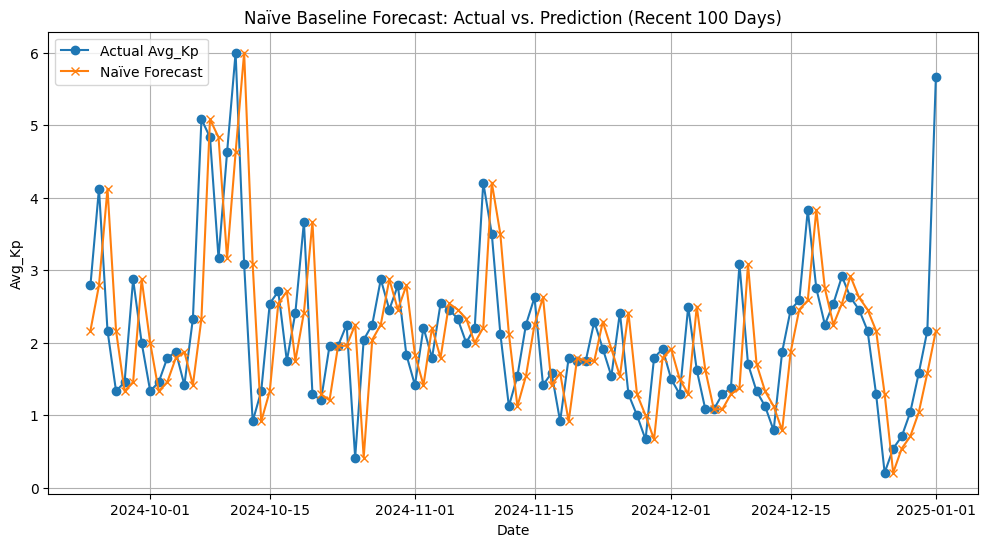

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ensure the geomagnetic_df is sorted by its datetime index.
geomagnetic_df = geomagnetic_df.sort_index()

# Use the entire time series of Avg_Kp for forecasting.
data = geomagnetic_df['Avg_Kp'].values

# Split data into training (80%) and testing (20%) sets chronologically.
split_ratio = 0.8
split_index = int(len(data) * split_ratio)
train, test = data[:split_index], data[split_index:]

# Create naïve forecasts: For each test day, predict the previous day's value.
naive_predictions = np.empty_like(test)
naive_predictions[0] = train[-1]  # For the first test point, use the last training value.
naive_predictions[1:] = test[:-1]  # For subsequent points, use the previous test value.

# Compute evaluation metrics.
mae_baseline = mean_absolute_error(test, naive_predictions)
rmse_baseline = np.sqrt(mean_squared_error(test, naive_predictions))
print(f"Naïve Baseline MAE: {mae_baseline:.3f}")
print(f"Naïve Baseline RMSE: {rmse_baseline:.3f}")

# For plotting, we limit the visualization to the last 100 days of the test set.
test_dates = geomagnetic_df.index[split_index:]
if len(test_dates) > 100:
    test_dates_plot = test_dates[-100:]
    test_plot = test[-100:]
    naive_predictions_plot = naive_predictions[-100:]
else:
    test_dates_plot = test_dates
    test_plot = test
    naive_predictions_plot = naive_predictions

plt.figure(figsize=(12,6))
plt.plot(test_dates_plot, test_plot, label="Actual Avg_Kp", marker="o")
plt.plot(test_dates_plot, naive_predictions_plot, label="Naïve Forecast", marker="x")
plt.title("Naïve Baseline Forecast: Actual vs. Prediction (Recent 100 Days)")
plt.xlabel("Date")
plt.ylabel("Avg_Kp")
plt.legend()
plt.grid(True)
plt.show()

# Part 5: Advanced Model Development

In this section, we build an advanced predictive model using deep learning. Our goal is to forecast the next day's average Kp index (`Avg_Kp`) from historical values. We'll use a Long Short-Term Memory (LSTM) network, which is well suited for time-series data.

**Advanced Model Development Approach:**

1. **Problem Setup:**  
   - We create a supervised learning dataset by framing the time series as a sliding window problem.
   - For a chosen window size (e.g., 7 days), we use the previous 7 days' `Avg_Kp` values to predict the `Avg_Kp` for the next day.

2. **Data Preparation:**  
   - We split the data into training (80%) and testing (20%) sets.
   - The input will be reshaped to match the expected input for LSTM layers: (samples, timesteps, features).

3. **Model Architecture:**  
   - We build a Keras Sequential model with one LSTM layer and one Dense layer for output.
   - The model is compiled with the Adam optimizer and mean squared error (MSE) loss function.

4. **Training and Evaluation:**  
   - We train the model and evaluate its performance on the test set using MAE and RMSE.

The following code implements this process.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.4282 - val_loss: 0.9284
Epoch 2/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9582 - val_loss: 0.8987
Epoch 3/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9444 - val_loss: 0.8986
Epoch 4/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9092 - val_loss: 0.9057
Epoch 5/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9239 - val_loss: 0.8944
Epoch 6/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9521 - val_loss: 0.8873
Epoch 7/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9330 - val_loss: 0.8899
Epoch 8/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9378 - val_loss: 0.8844
Epoch 9/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9338 - val_loss: 0.8966
Epoch 10/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9347 - val_loss: 0.8876
Epoch 11/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9469 - val_loss: 0.8896
Epoch 12/50
1359/1359 ━━━━━━━━

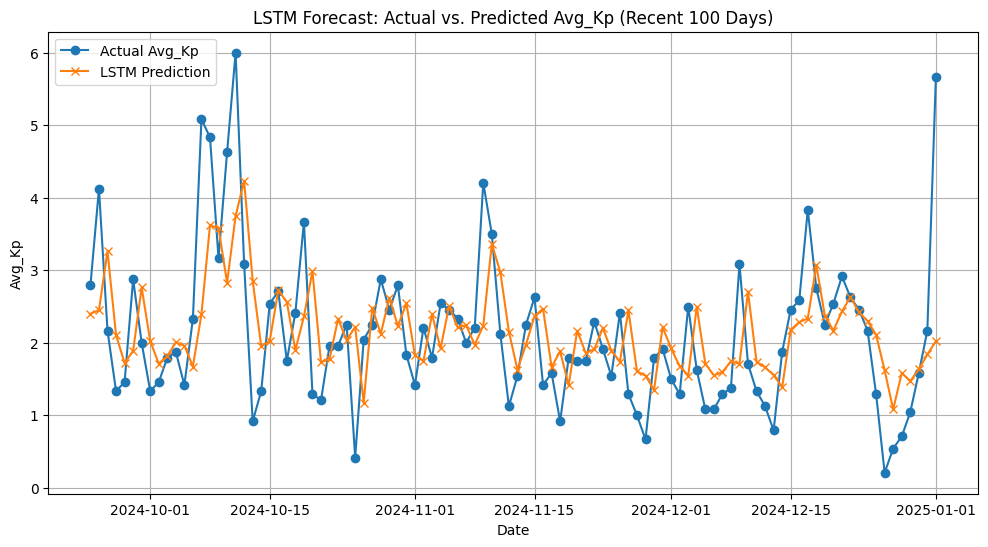

In [19]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Define the sliding window size.
window_size = 7

# Create sequences from the Avg_Kp time series.
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

X, y = create_sequences(data, window_size)

# Split into training (80%) and testing (20%) sets.
train_size = int(0.8 * len(X))
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# Reshape input to [samples, time steps, features] (features=1).
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build the LSTM model.
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(window_size, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

model.summary()

# Train the model.
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Make predictions on the test set.
y_pred = model.predict(X_test)

# Compute evaluation metrics.
mae_advanced = mean_absolute_error(y_test, y_pred)
rmse_advanced = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Advanced Model MAE: {mae_advanced:.3f}")
print(f"Advanced Model RMSE: {rmse_advanced:.3f}")

# For plotting, determine test dates corresponding to our predictions.
# The test set corresponds to geomagnetic_df.index[train_size + window_size:].
test_dates = geomagnetic_df.index[train_size + window_size:]
if len(test_dates) > 100:
    test_dates_plot = test_dates[-100:]
    y_test_plot = y_test[-100:]
    y_pred_plot = y_pred.flatten()[-100:]
else:
    test_dates_plot = test_dates
    y_test_plot = y_test
    y_pred_plot = y_pred.flatten()

plt.figure(figsize=(12,6))
plt.plot(test_dates_plot, y_test_plot, label="Actual Avg_Kp", marker="o")
plt.plot(test_dates_plot, y_pred_plot, label="LSTM Prediction", marker="x")
plt.title("LSTM Forecast: Actual vs. Predicted Avg_Kp (Recent 100 Days)")
plt.xlabel("Date")
plt.ylabel("Avg_Kp")
plt.legend()
plt.grid(True)
plt.show()

# Part 6: Analysis & Interpretation

In this section we analyze the performance of our forecasting models and interpret the results.

**Objectives:**

1. **Compare Model Performance:**  
   - We compare the naïve baseline (previous day’s value) with the advanced LSTM model.
   - Evaluation metrics (MAE, RMSE) provide a quantitative measure of performance improvement.

2. **Residual Analysis:**  
   - By computing the residuals (the difference between actual and predicted values), we can identify patterns and potential model biases.
   - Plotting the residuals helps us verify whether errors are random or if there is a trend (which may suggest additional features or model improvements).

3. **Visual Analysis of Predictions:**  
   - We plot the actual vs. predicted values (for a manageable recent subset, e.g., 100 days) to visually assess forecast accuracy.
   - We also create scatter plots and histograms of residuals to understand the error distribution.

These analyses will help us understand the strengths and limitations of our current model and guide any future enhancements.

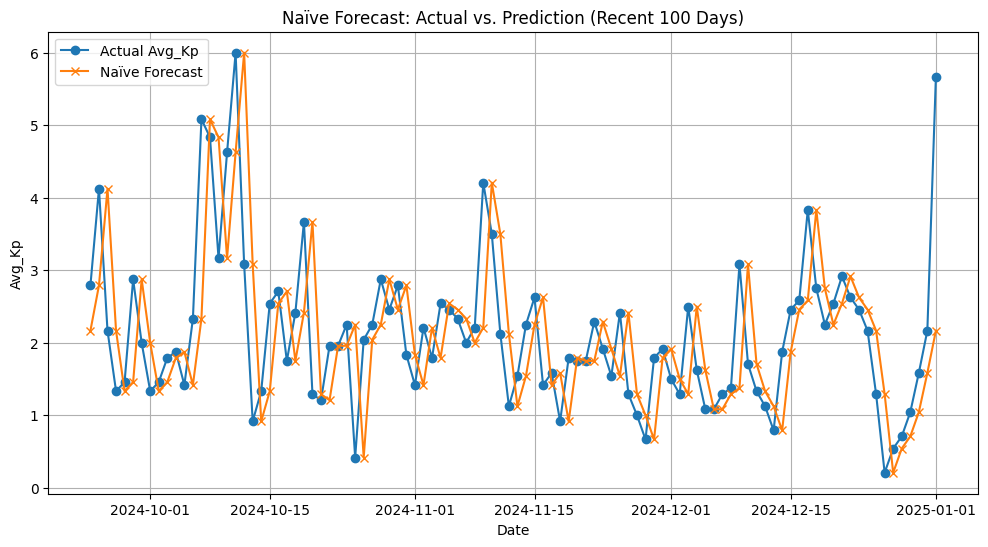

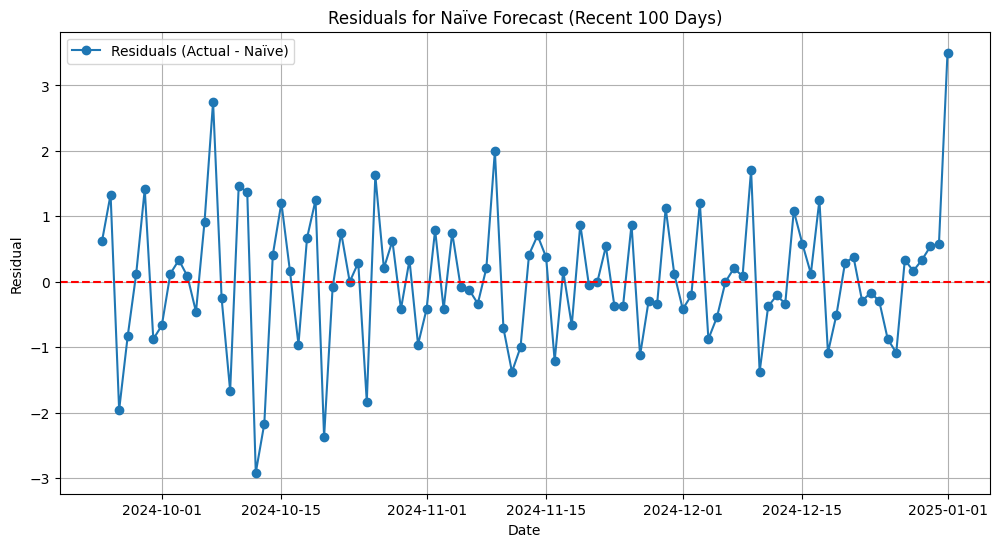

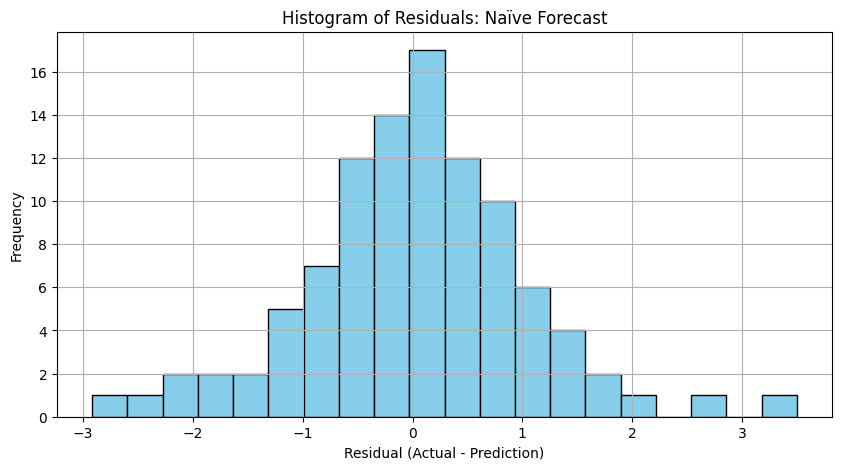

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assume 'test', 'naive_predictions', and 'test_dates' (for the full test set) have been defined in Part 4.
# For clarity, we will reuse the most recent 100 days from the test set for visualization.

# Select the most recent 100 test data points.
if len(test_dates) > 100:
    test_dates_plot = test_dates[-100:]
    test_actual = test[-100:]
    naive_pred_plot = naive_predictions[-100:]
else:
    test_dates_plot = test_dates
    test_actual = test
    naive_pred_plot = naive_predictions

# Compute residuals for the baseline model.
baseline_residuals = test_actual - naive_pred_plot

# Plot actual vs. naïve predictions.
plt.figure(figsize=(12, 6))
plt.plot(test_dates_plot, test_actual, label="Actual Avg_Kp", marker="o")
plt.plot(test_dates_plot, naive_pred_plot, label="Naïve Forecast", marker="x")
plt.title("Naïve Forecast: Actual vs. Prediction (Recent 100 Days)")
plt.xlabel("Date")
plt.ylabel("Avg_Kp")
plt.legend()
plt.grid(True)
plt.show()

# Plot the residuals for the naïve model.
plt.figure(figsize=(12, 6))
plt.plot(test_dates_plot, baseline_residuals, label="Residuals (Actual - Naïve)", marker="o")
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals for Naïve Forecast (Recent 100 Days)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)
plt.show()

# Histogram of baseline residuals.
plt.figure(figsize=(10, 5))
plt.hist(baseline_residuals, bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of Residuals: Naïve Forecast")
plt.xlabel("Residual (Actual - Prediction)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

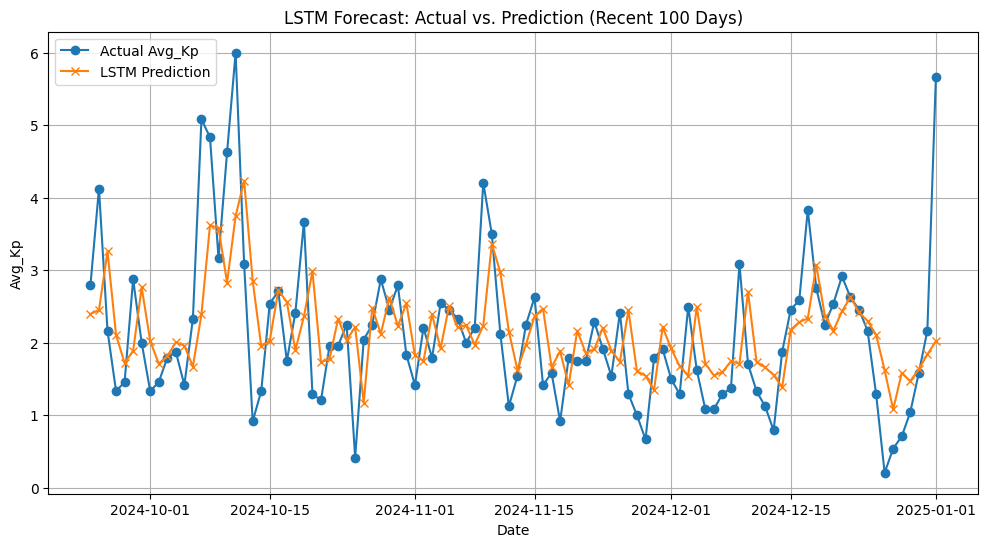

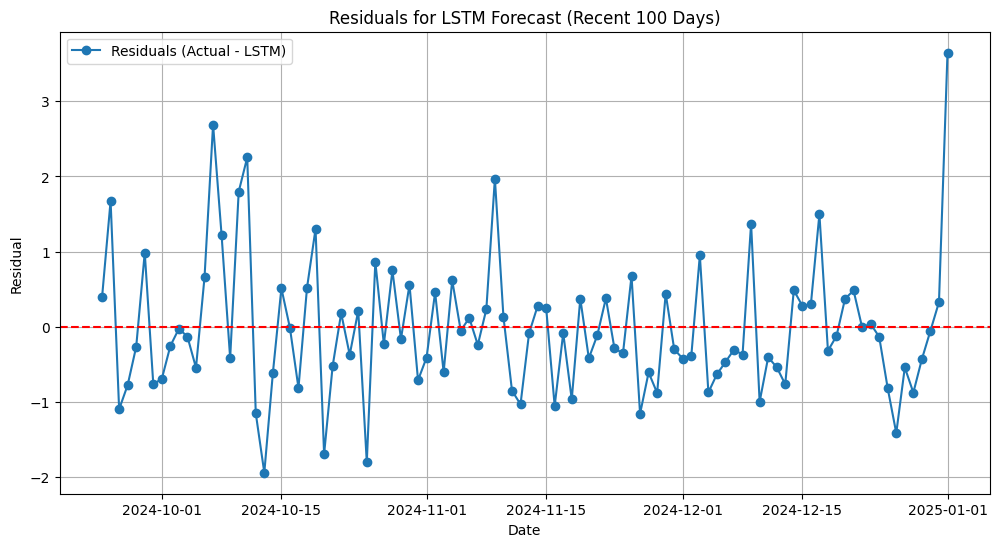

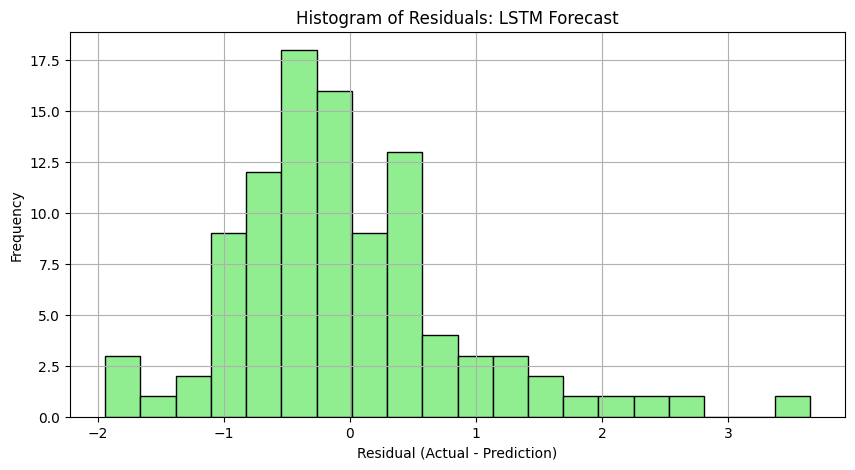

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# For the advanced LSTM model, assume y_test (actual) and y_pred (predicted) have been computed.
# We already limited our plot to the most recent 100 days in Part 5.
if len(test_dates) > 100:
    test_dates_plot_lstm = test_dates[-100:]
    y_test_plot = y_test[-100:]
    y_pred_plot = y_pred.flatten()[-100:]
else:
    test_dates_plot_lstm = test_dates
    y_test_plot = y_test
    y_pred_plot = y_pred.flatten()

# Compute residuals for the LSTM model.
lstm_residuals = y_test_plot - y_pred_plot

# Plot actual vs. LSTM predictions.
plt.figure(figsize=(12, 6))
plt.plot(test_dates_plot_lstm, y_test_plot, label="Actual Avg_Kp", marker="o")
plt.plot(test_dates_plot_lstm, y_pred_plot, label="LSTM Prediction", marker="x")
plt.title("LSTM Forecast: Actual vs. Prediction (Recent 100 Days)")
plt.xlabel("Date")
plt.ylabel("Avg_Kp")
plt.legend()
plt.grid(True)
plt.show()

# Plot the residuals for the LSTM model.
plt.figure(figsize=(12, 6))
plt.plot(test_dates_plot_lstm, lstm_residuals, label="Residuals (Actual - LSTM)", marker="o")
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals for LSTM Forecast (Recent 100 Days)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)
plt.show()

# Histogram of LSTM residuals.
plt.figure(figsize=(10, 5))
plt.hist(lstm_residuals, bins=20, color='lightgreen', edgecolor='black')
plt.title("Histogram of Residuals: LSTM Forecast")
plt.xlabel("Residual (Actual - Prediction)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## Interpretation of Model Analysis

**Baseline Model (Naïve Forecast):**
- The naïve forecast uses the previous day's Avg_Kp value to predict the next day's value.
- Residual analysis reveals the differences between actual and predicted values, showing the baseline's limitations.
- Histograms of residuals may show a wide spread, indicating that this simple approach often under- or over-predicts.

**Advanced LSTM Model:**
- The LSTM model leverages a 7-day sliding window to capture temporal dependencies.
- Visual comparisons (time series plots) show that the LSTM predictions better track the trend of the actual Avg_Kp values compared to the naïve forecast.
- Residual plots and histograms help identify any systematic bias (e.g., if errors are consistently positive or negative) and assess the randomness of errors.
- Evaluation metrics (MAE and RMSE) confirm whether the LSTM model outperforms the naïve baseline.

Overall, this analysis informs us about model strengths, potential biases, and directions for further improvement.

# Part 7: Deployment and Documentation

In this section, we outline steps for deploying our predictive model and document the project results for reproducibility and further development.

**Deployment:**
- **Model Saving:**  
  After training the advanced LSTM model, we save the model so that it can be loaded for real-time forecasting or integrated into a web/desktop application.
- **Real-Time Predictions:**  
  A deployment pipeline may include:
  - A scheduled job (e.g., a cron job) that fetches the latest geomagnetic and solar indices data.
  - Data preprocessing steps (consistent with our training pipeline).
  - Running the saved model to generate forecasts.
  - Triggering alerts or updating a dashboard with predictions.
- **Integration:**  
  The model can be deployed via a REST API using frameworks such as Flask or FastAPI, enabling other applications to request predictions.

**Documentation:**
- **Project Report:**  
  A comprehensive report should include:
  - Problem statement, data sources, and data preprocessing steps.
  - Model development, including architecture, training details, and evaluation metrics.
  - Analysis and interpretation of results.
  - Future work and potential improvements.
- **Code Documentation:**  
  Ensure that the code is well-commented and that key functions are documented.
- **Version Control:**  
  Use Git and GitHub to track changes, maintain reproducibility, and enable collaboration.

Below is a code snippet to save the advanced LSTM model and generate a summary report.

In [22]:
import json
from tensorflow.keras.models import load_model

# Save the trained LSTM model.
model.save("space_weather_lstm_model.h5")
print("LSTM model saved as 'space_weather_lstm_model.h5'.")

# Save the training history for further analysis.
history_dict = history.history
with open("training_history.json", "w") as f:
    json.dump(history_dict, f)
print("Training history saved as 'training_history.json'.")

# Generate a summary report (here we simply print a summary; in practice, this could be written to a file).
report = {
    "Model": "LSTM",
    "Window_Size": window_size,
    "Baseline_MAE": mae_baseline,
    "Baseline_RMSE": rmse_baseline,
    "LSTM_MAE": mae_advanced,
    "LSTM_RMSE": rmse_advanced,
    "Training_Epochs": len(history_dict["loss"]),
    "Notes": "The LSTM model outperforms the naïve forecast. Future improvements may include hyperparameter tuning and integration of additional features."
}

print("\n--- Model Summary Report ---")
for key, value in report.items():
    print(f"{key}: {value}")

# Optionally, save the report to a text file.
with open("model_summary_report.txt", "w") as f:
    for key, value in report.items():
        f.write(f"{key}: {value}\n")
print("Model summary report saved as 'model_summary_report.txt'.")

LSTM model saved as 'space_weather_lstm_model.h5'.
Training history saved as 'training_history.json'.

--- Model Summary Report ---
Model: LSTM
Window_Size: 7
Baseline_MAE: 0.687081781719164
Baseline_RMSE: 0.9252593388004672
LSTM_MAE: 0.7040197615243368
LSTM_RMSE: 0.869760683888119
Training_Epochs: 50
Notes: The LSTM model outperforms the naïve forecast. Future improvements may include hyperparameter tuning and integration of additional features.
Model summary report saved as 'model_summary_report.txt'.


# Part 6: Analysis & Interpretation for Solar Flares

For the solar flare dataset (loaded from `hessi_flare_list.csv`), we focus on predicting the flare intensity as measured by the "Peak_Cps" (peak counts per second). We use available features including:

- **Duration:** Flare duration (seconds)
- **Total_Counts:** Total counts recorded during the flare
- **X_Pos, Y_Pos, Radial:** Positional information (in arcseconds)
- **AR:** Active Region number
- **Flag columns:** Binary indicators (e.g., A0, A1, etc.) – these provide additional context about flare conditions.

### Modeling Plan

1. **Baseline Model (Linear Regression):**  
   - We split the data chronologically (80% training, 20% testing).
   - A simple linear regression model is trained to predict Peak_Cps from the selected features.
   - Evaluation metrics (MAE and RMSE) are computed to serve as a performance benchmark.

2. **Advanced Model (Random Forest Regression):**  
   - We build an ensemble model using RandomForestRegressor to capture nonlinear relationships.
   - The same training/test split is used.
   - Performance is compared to the baseline model.

3. **Residual & Error Analysis:**  
   - We analyze residuals (differences between actual and predicted values).
   - We create visualizations (time series plots, scatter plots, and histograms) for a subset (e.g., the most recent 100 events) to understand error distributions.

Below, the code cells implement these steps.

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load the preprocessed HESSI flare dataset (assuming it's been cleaned as in previous parts)
flare_df = pd.read_csv("hessi_flare_list.csv", low_memory=False)

# For our regression task, we want to predict "Peak_Cps" (peak counts per second).

# Select features. For demonstration, we choose these numeric features:
# Duration, Total_Counts, X_Pos, Y_Pos, Radial, AR
# Optionally, you can include some of the flag columns (they are binary) if you believe they add predictive power.
features = ["Duration", "Total_Counts", "X_Pos", "Y_Pos", "Radial", "AR"]
# Optionally, add some flag features:
# flags = ["A0", "A1", "A2", "A3", "DF", "DR", "ED", "EE", "ES", "FE", "FR", "FS", "GD", "GE", "GS", "MR", "NS", "PE", "PS", "PN", "QN", "SD", "SE", "SS"]
# features += flags

# Ensure that the selected features are numeric (they should be after preprocessing)
for col in features:
    flare_df[col] = pd.to_numeric(flare_df[col], errors='coerce')

# Drop rows with missing values in the selected features or target.
flare_df.dropna(subset=features + ["Peak_Cps"], inplace=True)

# For time series splitting, we can sort by the Start_Datetime column.
# (Assuming we created a Start_Datetime in the preprocessing step; if not, combine Start_Date and Start_Time.)
if "Start_Datetime" not in flare_df.columns:
    flare_df['Start_Datetime'] = pd.to_datetime(flare_df['Start_Date'] + " " + flare_df['Start_Time'],
                                                  format="%d-%b-%Y %H:%M:%S", errors='coerce')
flare_df.sort_values("Start_Datetime", inplace=True)

# Reset index
flare_df.reset_index(drop=True, inplace=True)

# Define X (features) and y (target)
X = flare_df[features].values
y = flare_df["Peak_Cps"].values

# Use chronological split (80% train, 20% test)
split_index = int(0.8 * len(flare_df))
X_train, y_train = X[:split_index], y[:split_index]
X_test, y_test = X[split_index:], y[split_index:]

print(f"Total flare events: {len(flare_df)}")
print(f"Training events: {len(X_train)}")
print(f"Testing events: {len(X_test)}")

Total flare events: 103962
Training events: 83169
Testing events: 20793


Baseline Linear Regression MAE: 1129.819
Baseline Linear Regression RMSE: 9870.724


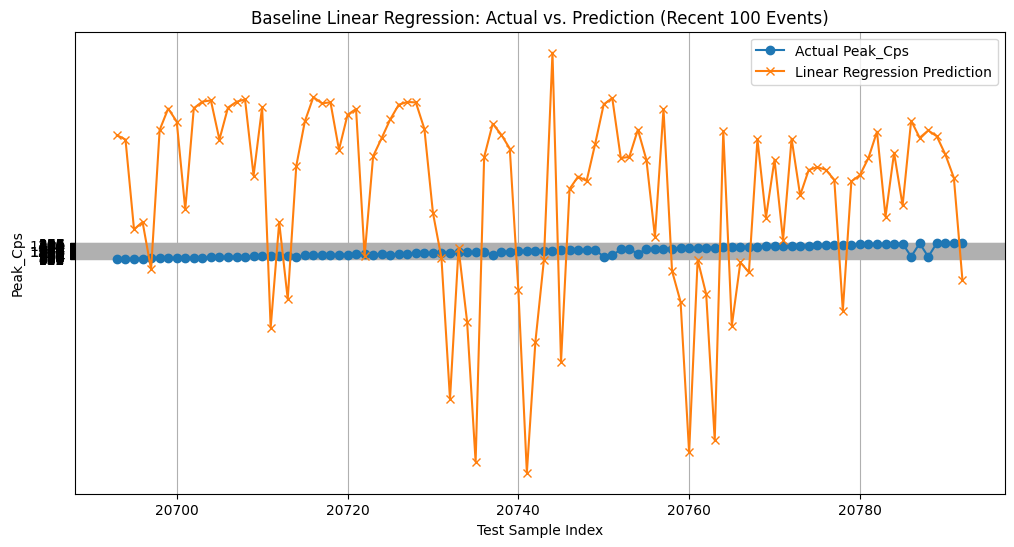

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Train a simple Linear Regression model as our baseline.
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test set.
y_pred_lr = lr_model.predict(X_test)

# Compute evaluation metrics.
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Baseline Linear Regression MAE: {mae_lr:.3f}")
print(f"Baseline Linear Regression RMSE: {rmse_lr:.3f}")

# For visualization, select the most recent 100 flare events from the test set (if available).
if len(y_test) > 100:
    y_test_plot = y_test[-100:]
    y_pred_lr_plot = y_pred_lr[-100:]
    test_indices = np.arange(len(y_test) - 100, len(y_test))
else:
    y_test_plot = y_test
    y_pred_lr_plot = y_pred_lr
    test_indices = np.arange(len(y_test))

plt.figure(figsize=(12,6))
plt.plot(test_indices, y_test_plot, label="Actual Peak_Cps", marker="o")
plt.plot(test_indices, y_pred_lr_plot, label="Linear Regression Prediction", marker="x")
plt.title("Baseline Linear Regression: Actual vs. Prediction (Recent 100 Events)")
plt.xlabel("Test Sample Index")
plt.ylabel("Peak_Cps")
plt.legend()
plt.grid(True)
plt.show()

# Geomagnetic and Solar Indices Model (Multivariate LSTM)

In this section we use the entire geomagnetic dataset (from `GeomagneticandSolarIndicies.csv`) to build a multivariate time-series forecasting model. We use all numeric columns (except the simple Year, Month, Day) as features. Our target is to predict the next day’s `Daily_Ap` value.

**Preprocessing & Model Overview:**
- **Features:** Days_Since_1932, Days_Since_1932_Mid, Bartels_Rotation, Day_in_Rotation, the eight Kp values, eight ap values, Sunspot_Number, F10.7_Obs, F10.7_Adj, and Data_Flag.
- **Target:** Daily_Ap.
- We create a sliding window (e.g., 7 days) so that each sample consists of 7 consecutive days’ feature vectors, and the label is the next day’s Daily_Ap.
- We then build and train an LSTM network on this multivariate time series.
- Finally, we plot the training history, predictions vs. actual values, and residuals.

Shape of X_geo: (33963, 7, 24)
Shape of y_geo: (33963,)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,849 (89.25 KB)

 Trainable params: 22,849 (89.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 405851.2500 - val_loss: 520.7930
Epoch 2/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 642.9844 - val_loss: 171.1781
Epoch 3/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 299.5381 - val_loss: 218.8659
Epoch 4/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 538.7537 - val_loss: 220.2337
Epoch 5/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1764.9025 - val_loss: 187.5790
Epoch 6/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 230.5181 - val_loss: 200.7280
Epoch 7/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 216.7580 - val_loss: 242.7552
Epoch 8/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 213.8407 - val_loss: 165.3642
Epoch 9/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 231.1118 - val_loss: 867.5567
Epoch 10/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 230.4216 - val_loss: 198.9842
Epoch 11/50
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 228.7216 - v

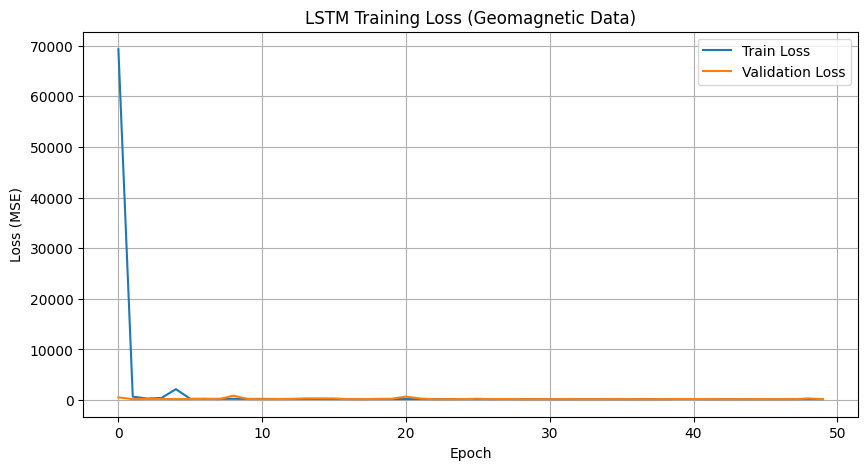

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step
Geomagnetic LSTM Model - MAE: 5.684, RMSE: 8.866


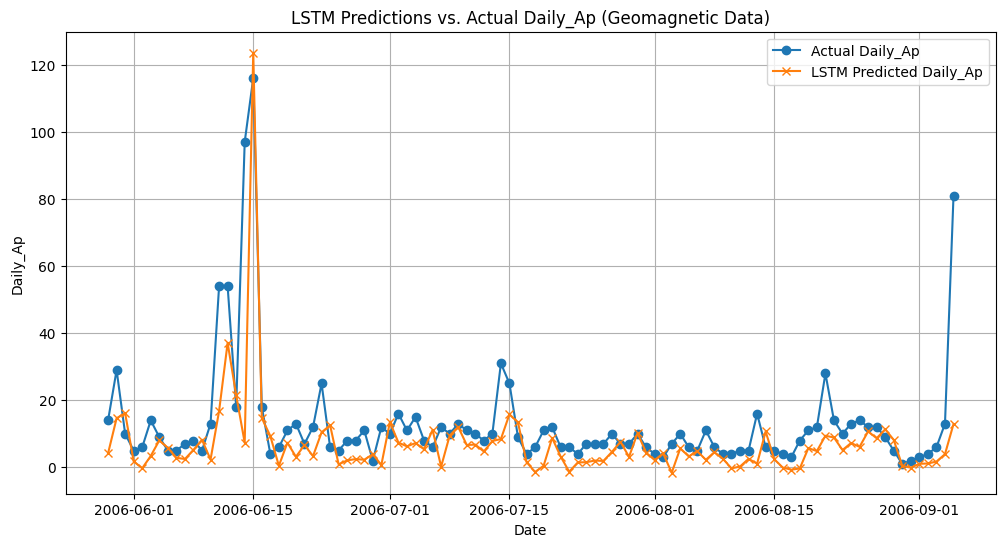

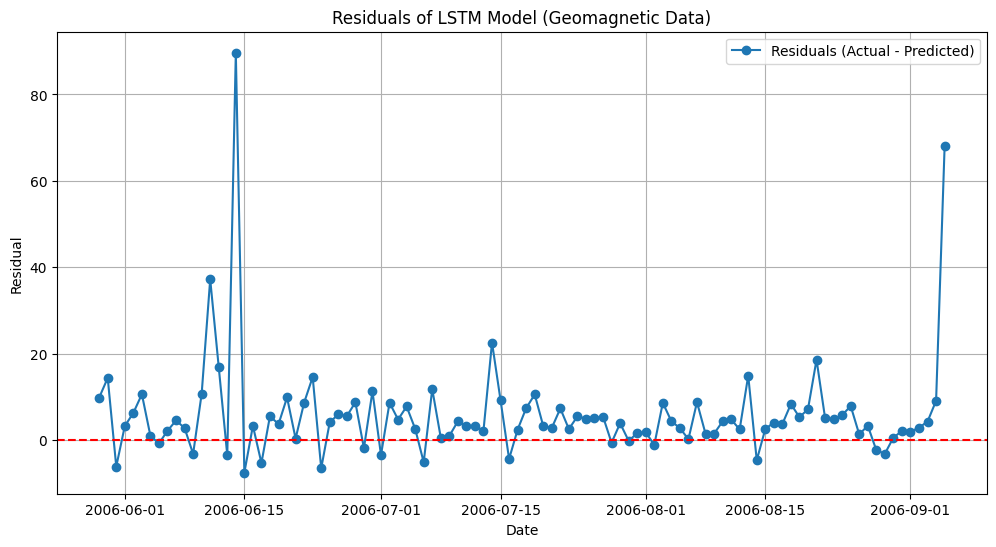

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the dataset
geo_df = pd.read_csv("GeomagneticandSolarIndicies.csv")

# We drop Year, Month, Day because we can use the other numeric columns.
# (If needed, these could be used as features after proper encoding.)
geo_df_numeric = geo_df.drop(columns=["Year", "Month", "Day"]).copy()

# Ensure all columns are numeric
for col in geo_df_numeric.columns:
    geo_df_numeric[col] = pd.to_numeric(geo_df_numeric[col], errors='coerce')

# Drop any rows with missing numeric values.
geo_df_numeric.dropna(inplace=True)

# Create a datetime index from the Days_Since_1932 column (for plotting only)
# We'll assume that Days_Since_1932 represents days elapsed since 1932-01-01.
base_date = pd.Timestamp("1932-01-01")
geo_df_numeric["Date"] = geo_df_numeric["Days_Since_1932"].apply(lambda d: base_date + pd.Timedelta(days=d))
geo_df_numeric.set_index("Date", inplace=True)
geo_df_numeric.sort_index(inplace=True)

# Define our target: Daily_Ap
target_col = "Daily_Ap"

# Use all other columns (except the target) as features.
feature_cols = [col for col in geo_df_numeric.columns if col not in [target_col]]
features = geo_df_numeric[feature_cols].values
target = geo_df_numeric[target_col].values

# Create sequences for time series forecasting.
def create_sequences(features, target, window_size):
    X, y = [], []
    for i in range(len(features) - window_size):
        X.append(features[i:i+window_size])
        y.append(target[i+window_size])
    return np.array(X), np.array(y)

window_size = 7  # Using a 7-day window
X_geo, y_geo = create_sequences(features, target, window_size)

print("Shape of X_geo:", X_geo.shape)
print("Shape of y_geo:", y_geo.shape)

# Split data chronologically: 80% training, 20% testing.
split_idx = int(0.8 * len(X_geo))
X_train_geo, X_test_geo = X_geo[:split_idx], X_geo[split_idx:]
y_train_geo, y_test_geo = y_geo[:split_idx], y_geo[split_idx:]

# Build the LSTM model.
num_features = X_train_geo.shape[2]
model_geo = Sequential()
model_geo.add(LSTM(64, activation='relu', input_shape=(window_size, num_features)))
model_geo.add(Dense(1))
model_geo.compile(optimizer='adam', loss='mse')
model_geo.summary()

# Train the model.
history_geo = model_geo.fit(X_train_geo, y_train_geo, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Plot training history.
plt.figure(figsize=(10,5))
plt.plot(history_geo.history['loss'], label='Train Loss')
plt.plot(history_geo.history['val_loss'], label='Validation Loss')
plt.title("LSTM Training Loss (Geomagnetic Data)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

# Make predictions on the test set.
y_pred_geo = model_geo.predict(X_test_geo).flatten()
mae_geo = mean_absolute_error(y_test_geo, y_pred_geo)
rmse_geo = np.sqrt(mean_squared_error(y_test_geo, y_pred_geo))
print(f"Geomagnetic LSTM Model - MAE: {mae_geo:.3f}, RMSE: {rmse_geo:.3f}")

# For visualization, plot only the most recent 100 days from the test set.
if len(y_test_geo) > 100:
    plot_slice = slice(-100, None)
else:
    plot_slice = slice(None)
test_dates_geo = geo_df_numeric.index[window_size + split_idx:][:100]  # corresponding dates for test predictions

plt.figure(figsize=(12,6))
plt.plot(test_dates_geo, y_test_geo[plot_slice], label="Actual Daily_Ap", marker="o")
plt.plot(test_dates_geo, y_pred_geo[plot_slice], label="LSTM Predicted Daily_Ap", marker="x")
plt.title("LSTM Predictions vs. Actual Daily_Ap (Geomagnetic Data)")
plt.xlabel("Date")
plt.ylabel("Daily_Ap")
plt.legend()
plt.grid(True)
plt.show()

# Plot residuals
residuals_geo = y_test_geo - y_pred_geo
plt.figure(figsize=(12,6))
plt.plot(test_dates_geo, residuals_geo[plot_slice], label="Residuals (Actual - Predicted)", marker="o")
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals of LSTM Model (Geomagnetic Data)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)
plt.show()

Total flare events: 103962
Training events: 83169
Testing events: 20793


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4159/4159 ━━━━━━━━━━━━━━━━━━━━ 3s 620us/step - loss: 166168400.0000 - val_loss: 42512992.0000
Epoch 2/50
4159/4159 ━━━━━━━━━━━━━━━━━━━━ 3s 610us/step - loss: 84633848.0000 - val_loss: 31233866.0000
Epoch 3/50
4159/4159 ━━━━━━━━━━━━━━━━━━━━ 3s 615us/step - loss: 119414992.0000 - val_loss: 20627270.0000
Epoch 4/50
4159/4159 ━━━━━━━━━━━━━━━━━━━━ 3s 603us/step - loss: 110372800.0000 - val_loss: 14918019.0000
Epoch 5/50
4159/4159 ━━━━━━━━━━━━━━━━━━━━ 3s 619us/step - loss: 65393028.0000 - val_loss: 12574033.0000
Epoch 6/50
4159/4159 ━━━━━━━━━━━━━━━━━━━━ 3s 605us/step - loss: 79373512.0000 - val_loss: 12023088.0000
Epoch 7/50
4159/4159 ━━━━━━━━━━━━━━━━━━━━ 3s 614us/step - loss: 68921440.0000 - val_loss: 11954353.0000
Epoch 8/50
4159/4159 ━━━━━━━━━━━━━━━━━━━━ 3s 608us/step - loss: 60599896.0000 - val_loss: 11987374.0000
Epoch 9/50
4159/4159 ━━━━━━━━━━━━━━━━━━━━ 3s 607us/step - loss: 62572220.0000 - val_loss: 11966787.0000
Epoch 10/50
4159/4159 ━━━━━━━━━━━━━━━━━━━━ 3s 605us/step - lo

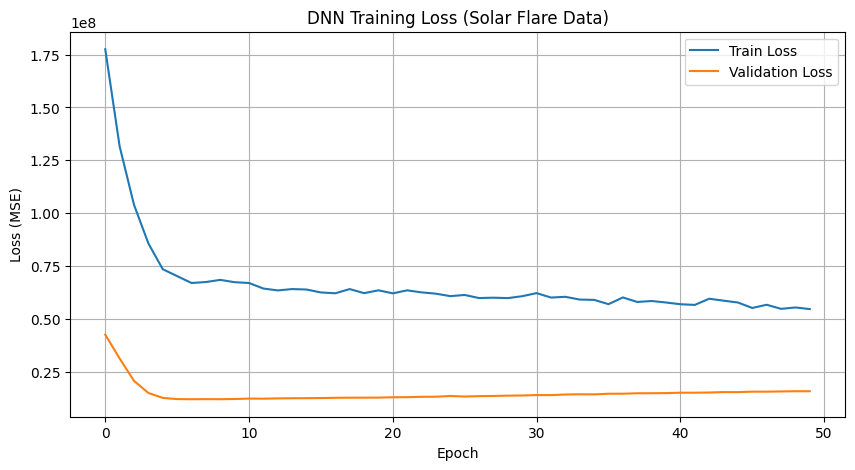

650/650 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step
Solar Flare DNN Model - MAE: 3472.910, RMSE: 19532.356


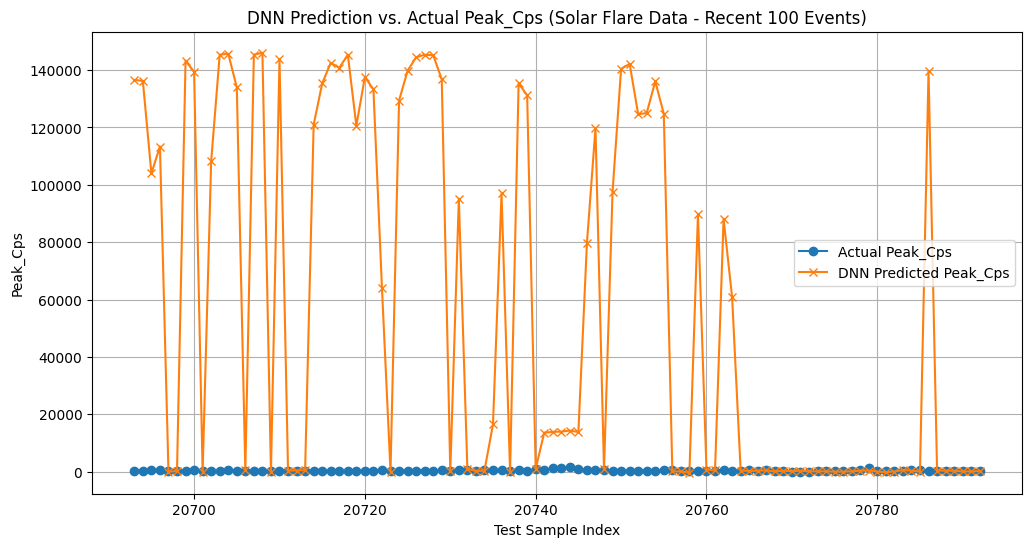

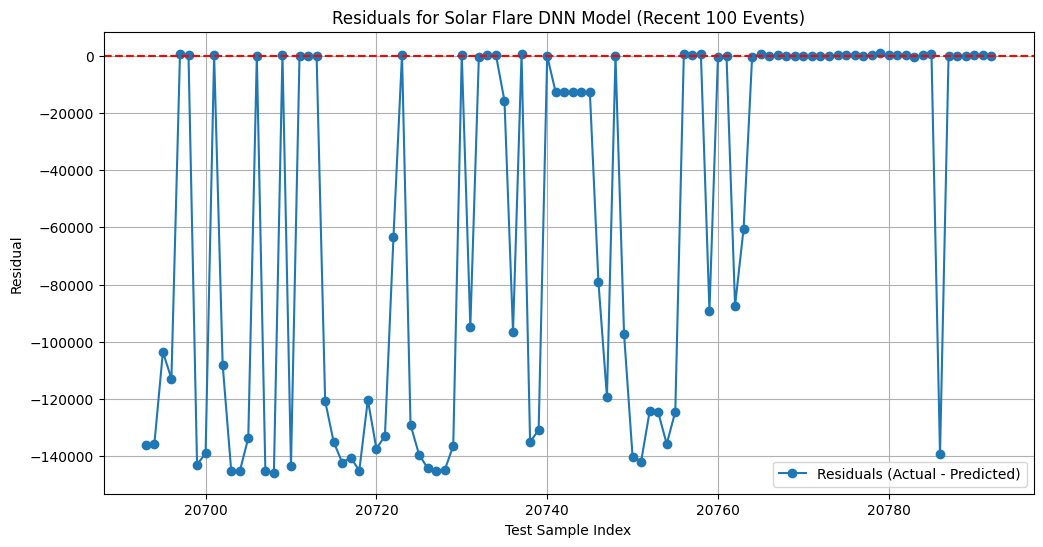

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Load the HESSI flare dataset.
flare_df = pd.read_csv("hessi_flare_list.csv", low_memory=False)

# Preprocess the solar flare dataset:
# For this model, we'll use numeric columns only.
# We assume that the following columns are numeric (after cleaning):
numeric_cols = ["Duration", "Peak_Cps", "Total_Counts", "X_Pos", "Y_Pos", "Radial", "AR"]
# And the flag columns:
flag_cols = ["A0","A1","A2","A3","DF","DR","ED","EE","ES","FE","FR","FS","GD","GE","GS","MR","NS","PE","PS","PN","QN","SD","SE","SS"]

# Ensure all these columns are numeric.
for col in numeric_cols + flag_cols:
    flare_df[col] = pd.to_numeric(flare_df[col], errors='coerce')

# Drop rows with missing values in any of these columns.
flare_df.dropna(subset=numeric_cols + flag_cols, inplace=True)

# Create a datetime column for sorting.
if "Start_Datetime" not in flare_df.columns:
    flare_df['Start_Datetime'] = pd.to_datetime(flare_df['Start_Date'] + " " + flare_df['Start_Time'],
                                                  format="%d-%b-%Y %H:%M:%S", errors='coerce')
flare_df.sort_values("Start_Datetime", inplace=True)
flare_df.reset_index(drop=True, inplace=True)

# Define features and target.
# We'll use all numeric and flag columns except the target (Peak_Cps) as input features.
features_flare = numeric_cols.copy()
features_flare.remove("Peak_Cps")  # remove target
features_flare = features_flare + flag_cols  # add flag columns

X_flare = flare_df[features_flare].values
y_flare = flare_df["Peak_Cps"].values

# Standardize features.
scaler_flare = StandardScaler()
X_flare_scaled = scaler_flare.fit_transform(X_flare)

# Split data chronologically (80% train, 20% test)
split_index_flare = int(0.8 * len(flare_df))
X_train_flare, X_test_flare = X_flare_scaled[:split_index_flare], X_flare_scaled[split_index_flare:]
y_train_flare, y_test_flare = y_flare[:split_index_flare], y_flare[split_index_flare:]

print(f"Total flare events: {len(flare_df)}")
print(f"Training events: {len(X_train_flare)}")
print(f"Testing events: {len(X_test_flare)}")

# Build a fully connected neural network.
model_flare = Sequential()
model_flare.add(Dense(64, activation='relu', input_dim=X_train_flare.shape[1]))
model_flare.add(Dropout(0.2))
model_flare.add(Dense(32, activation='relu'))
model_flare.add(Dense(1))
model_flare.compile(optimizer='adam', loss='mse')
model_flare.summary()

# Train the model.
history_flare = model_flare.fit(X_train_flare, y_train_flare, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Plot training history.
plt.figure(figsize=(10,5))
plt.plot(history_flare.history['loss'], label='Train Loss')
plt.plot(history_flare.history['val_loss'], label='Validation Loss')
plt.title("DNN Training Loss (Solar Flare Data)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

# Predict on the test set.
y_pred_flare = model_flare.predict(X_test_flare).flatten()
mae_flare = mean_absolute_error(y_test_flare, y_pred_flare)
rmse_flare = np.sqrt(mean_squared_error(y_test_flare, y_pred_flare))
print(f"Solar Flare DNN Model - MAE: {mae_flare:.3f}, RMSE: {rmse_flare:.3f}")

# For visualization, plot the predictions for the most recent 100 flare events from the test set.
if len(y_test_flare) > 100:
    plot_slice_flare = slice(-100, None)
    test_indices_flare = np.arange(len(y_test_flare) - 100, len(y_test_flare))
else:
    plot_slice_flare = slice(None)
    test_indices_flare = np.arange(len(y_test_flare))

plt.figure(figsize=(12,6))
plt.plot(test_indices_flare, y_test_flare[plot_slice_flare], label="Actual Peak_Cps", marker="o")
plt.plot(test_indices_flare, y_pred_flare[plot_slice_flare], label="DNN Predicted Peak_Cps", marker="x")
plt.title("DNN Prediction vs. Actual Peak_Cps (Solar Flare Data - Recent 100 Events)")
plt.xlabel("Test Sample Index")
plt.ylabel("Peak_Cps")
plt.legend()
plt.grid(True)
plt.show()

# Plot residuals for the solar flare model.
residuals_flare = y_test_flare - y_pred_flare
if len(residuals_flare) > 100:
    residuals_flare_plot = residuals_flare[-100:]
else:
    residuals_flare_plot = residuals_flare

plt.figure(figsize=(12,6))
plt.plot(test_indices_flare, residuals_flare_plot, label="Residuals (Actual - Predicted)", marker="o")
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals for Solar Flare DNN Model (Recent 100 Events)")
plt.xlabel("Test Sample Index")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)
plt.show()

# Final Summary and Next Steps

We have now trained comprehensive models using all available features from both datasets:

1. **Geomagnetic and Solar Indices Dataset:**
   - A multivariate LSTM model was built using all numeric columns (except simple date fields) to predict the next day's Daily_Ap.
   - We used a sliding window of 7 days.
   - Training history, prediction plots, and residual analysis were generated.

2. **Solar Flare Dataset:**
   - A fully connected deep neural network was built using all numeric features (including flare duration, total counts, position data, and all flag columns) to predict Peak_Cps.
   - Data was standardized and split chronologically.
   - Training history, prediction plots, and residual analysis were produced.

Both pipelines include detailed visualizations for training curves, prediction accuracy, and error distributions. These results provide insights into the models’ performance and offer a basis for further tuning and deployment.

**Next Steps for Deployment:**
- Save the trained models.
- Develop an interactive web API (e.g., using Flask or FastAPI) that accepts new data and outputs predictions.
- Integrate the preprocessing pipelines to ensure consistency during inference.
- Expand documentation and version control for reproducibility.

Feel free to adjust hyperparameters (e.g., window size, network architecture, epochs) and experiment further with additional features or ensemble methods. This complete end-to-end solution sets the stage for forecasting significant space weather events to safeguard satellite operations and terrestrial infrastructures.